# 1. Install Dependencies

In [ ]:
# 1. Install correct dependencies
!pip install numpy==1.26.4 expelliarmus spikingjelly tonic h5py importrosbag pbr --quiet --force-reinstall

# 2. Hard exit the active Python process to force Colab to reload its memory completely
import os
os._exit(0)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 141.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 26.9 MB/s eta 0:00:

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import tonic
import tonic.transforms as tonic_transforms
from torch.utils.data import DataLoader
from spikingjelly.activation_based import neuron, functional, surrogate, layer
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Success! Using device: {DEVICE}")

Success! Using device: cuda


# 2. Hyperparameters & Config
*Tweak these parameters later to independentally optimize your model's accuracy.*

In [ ]:
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 10

# SNN Specifics (Exactly matched to your old project run)
TIME_STEPS = 16   # (T) Matching your friend's temporal layout
TAU = 2.0         # Membrane decay time constant (τ)
V_THRESHOLD = 0.5 # Matched to old project threshold configuration!

# 3. Dataset Pipeline (N-MNIST)
*Downloads and prepares the sparse event-camera frames using Tonic.*

In [ ]:
print("Initializing N-MNIST dataset...")

frame_transform = tonic_transforms.ToFrame(
    sensor_size=tonic.datasets.NMNIST.sensor_size,
    n_time_bins=TIME_STEPS,
)

train_raw = tonic.datasets.NMNIST(save_to='./data', train=True, transform=frame_transform)
test_raw  = tonic.datasets.NMNIST(save_to='./data', train=False, transform=frame_transform)

train_dataset = tonic.DiskCachedDataset(train_raw, cache_path="./data/cache_train")
test_dataset  = tonic.DiskCachedDataset(test_raw, cache_path="./data/cache_test")

def collate_fn(batch):
    samples, labels = zip(*batch)
    x = torch.stack([torch.tensor(s, dtype=torch.float32) for s in samples])
    y = torch.tensor(labels, dtype=torch.long)
    return x, y

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, drop_last=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Initializing N-MNIST dataset...


  0%|          | 0/1011893601 [00:00<?, ?it/s]

Extracting ./data/NMNIST/train.zip to ./data/NMNIST


  0%|          | 0/169674850 [00:00<?, ?it/s]

Extracting ./data/NMNIST/test.zip to ./data/NMNIST
Train samples: 60000 | Test samples: 10000


# 4. SNN Model Architecture Swapping to the Wider 3-Layer Architecture + Batch Normalization


In [ ]:
class StandaloneSpikingJellyNet(nn.Module):
    def __init__(self, input_features=2*34*34, hidden_size=256, output_classes=10):
        super().__init__()

        # Upgraded wider network + fixed Sequence containers for standard BatchNorm1d
        self.network = nn.Sequential(
            layer.Flatten(), # [T, B, 2, 34, 34] -> [T, B, 2312]

            # Layer 1: Wide representation layer
            layer.Linear(input_features, hidden_size),
            layer.SeqToANNContainer(nn.BatchNorm1d(hidden_size)),
            neuron.LIFNode(tau=TAU, v_threshold=V_THRESHOLD, surrogate_function=surrogate.ATan(), detach_reset=True),

            # Layer 2: Core processing layer
            layer.Linear(hidden_size, hidden_size),
            layer.SeqToANNContainer(nn.BatchNorm1d(hidden_size)),
            neuron.LIFNode(tau=TAU, v_threshold=V_THRESHOLD, surrogate_function=surrogate.ATan(), detach_reset=True),

            # Output Layer (10 classes)
            layer.Linear(hidden_size, output_classes),
            neuron.LIFNode(tau=TAU, v_threshold=V_THRESHOLD, surrogate_function=surrogate.ATan(), detach_reset=True)
        )

    def forward(self, x):
        x = x.permute(1, 0, 2, 3, 4)
        out_spikes = self.network(x)
        return out_spikes.mean(dim=0)

# Initialize and map
model = StandaloneSpikingJellyNet()
functional.set_step_mode(model, step_mode='m')
model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# 5. Training and Evaluation Loop

In [ ]:
print("Starting Isolated SNN Optimization...\n")
train_accs, test_accs = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        functional.reset_net(model) # Essential SpikingJelly cleanup step

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    train_accs.append(train_acc)

    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            functional.reset_net(model)
            outputs = model(images)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    test_acc = 100. * test_correct / test_total
    test_accs.append(test_acc)
    print(f"Epoch [{epoch}/{EPOCHS}] | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Starting Isolated SNN Optimization...

Epoch [1/10] | Loss: 1.5938 | Train Acc: 91.85% | Test Acc: 95.89%
Epoch [2/10] | Loss: 1.5259 | Train Acc: 96.51% | Test Acc: 96.69%
Epoch [3/10] | Loss: 1.5135 | Train Acc: 97.26% | Test Acc: 96.95%
Epoch [4/10] | Loss: 1.5060 | Train Acc: 97.73% | Test Acc: 97.52%
Epoch [5/10] | Loss: 1.5016 | Train Acc: 97.98% | Test Acc: 97.53%
Epoch [6/10] | Loss: 1.4979 | Train Acc: 98.22% | Test Acc: 97.65%
Epoch [7/10] | Loss: 1.4955 | Train Acc: 98.43% | Test Acc: 97.75%
Epoch [8/10] | Loss: 1.4938 | Train Acc: 98.51% | Test Acc: 97.89%
Epoch [9/10] | Loss: 1.4919 | Train Acc: 98.62% | Test Acc: 97.68%
Epoch [10/10] | Loss: 1.4904 | Train Acc: 98.76% | Test Acc: 97.88%


# 6. Plot Results

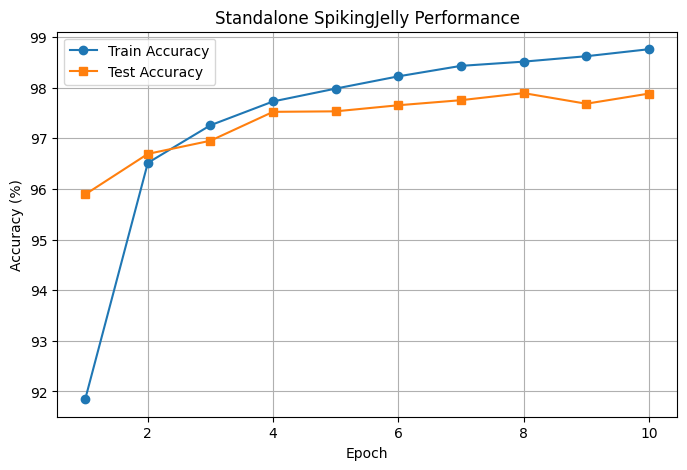

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_accs, label="Train Accuracy", marker='o')
plt.plot(range(1, EPOCHS + 1), test_accs, label="Test Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Standalone SpikingJelly Performance")
plt.legend()
plt.grid(True)
plt.show()